In [ ]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 38.1 MB/s eta 0:00:00


In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 76.4 MB/s eta 0:00:00


In [ ]:
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import ChemicalFeatures
from rdkit import RDConfig
import os

def one_hot(value, allowable_set, unknown=False):
    if unknown:
        result = [0.0] * (len(allowable_set) + 1)
        if value in allowable_set:
            index = allowable_set.index(value)
            result[index] = 1.0
        else:
            result[-1] = 1.0
        return result
    else:
        result = [0.0] * len(allowable_set)
        if value in allowable_set:
            index = allowable_set.index(value)
            result[index] = 1.0
        return result


def atom_type_features(mol):
    allowable = ["C","N","O","F","P","S","Cl","Br","I"]
    features = []

    for atom in mol.GetAtoms():
        value = atom.GetSymbol()
        features.append(one_hot(value,allowable,unknown=True))
    return torch.tensor(features,dtype=torch.float32)


def formal_charge_features(mol):
    allowable = [-2, -1, 0, 1, 2]
    features = []

    for atom in mol.GetAtoms():
        value = atom.GetFormalCharge()
        features.append(one_hot(value,allowable,unknown=False))
    return torch.tensor(features,dtype=torch.float32)


def hybridization_features(mol):
    allowable = ["SP","SP2","SP3"]
    features = []

    for atom in mol.GetAtoms():
        value = str(atom.GetHybridization())
        features.append( one_hot(value,allowable,unknown=False) )
    return torch.tensor(features,dtype=torch.float32)


_FEATURE_FACTORY = None

def get_feature_factory():
    global _FEATURE_FACTORY
    if _FEATURE_FACTORY is None:
        _FEATURE_FACTORY = ChemicalFeatures.BuildFeatureFactory( os.path.join(RDConfig.RDDataDir, "BaseFeatures.fdef"))
    return _FEATURE_FACTORY


def hydrogen_bond_features(mol):
    factory = get_feature_factory()
    rdkit_features = factory.GetFeaturesForMol(mol)
    features = [[0.0, 0.0] for _ in mol.GetAtoms()]

    for feature in rdkit_features:
        atom_id = feature.GetAtomIds()[0]
        family = feature.GetFamily()
        if family == "Donor":
            features[atom_id][0] = 1.0
        elif family == "Acceptor":
            features[atom_id][1] = 1.0
    return torch.tensor(features, dtype=torch.float32)


def aromatic_features(mol):
    features = []

    for atom in mol.GetAtoms():
        features.append([float(atom.GetIsAromatic())])
    return torch.tensor(features,dtype=torch.float32)


def degree_features(mol):
    allowable = [1,2,3,4,5]
    features = []

    for atom in mol.GetAtoms():
        value = atom.GetTotalDegree()
        features.append(one_hot( value,allowable,unknown=True))
    return torch.tensor(features,dtype=torch.float32)

def hydrogen_count_features(mol):
    allowable = [0,1,2,3]
    features = []

    for atom in mol.GetAtoms():
        value = atom.GetTotalNumHs()
        features.append(one_hot(value,allowable,unknown=False))
    return torch.tensor(features, dtype=torch.float32)


def chirality_features(mol):
    features = []

    for atom in mol.GetAtoms():
        feature = [0.0, 0.0]
        if atom.HasProp("_CIPCode"):
            code = atom.GetProp("_CIPCode")
            if code == "R":
                feature[0] = 1.0
            elif code == "S":
                feature[1] = 1.0
        features.append(feature)

    return torch.tensor(features,dtype=torch.float32)


def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    if mol.GetNumAtoms() <= 1:
        return None

    atom_type = atom_type_features(mol)
    formal_charge = formal_charge_features(mol)
    hybridization = hybridization_features(mol)
    hydrogen_bond = hydrogen_bond_features(mol)
    aromatic = aromatic_features(mol)
    degree = degree_features(mol)
    hydrogen_count = hydrogen_count_features(mol)
    chirality = chirality_features(mol)

    node_features = torch.cat([ atom_type, formal_charge,hybridization, hydrogen_bond,aromatic, degree,hydrogen_count, chirality],dim=1)

    src = []
    dst = []

    for bond in mol.GetBonds():
        start = bond.GetBeginAtomIdx()
        end = bond.GetEndAtomIdx()

        src.append(start)
        dst.append(end)

        src.append(end)
        dst.append(start)

    edge_index = torch.tensor(
        [src, dst],
        dtype=torch.long
    )

    return node_features, edge_index

In [ ]:
import pandas as pd
import torch
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split


def load_data(path):
    df = pd.read_excel(path)
    graphs = []
    for _, row in df.iterrows():
        graph = smiles_to_graph(row["SMILES"])
        if graph is None:
            continue

        node_features, edge_index = graph
        data = Data( x=node_features,edge_index=edge_index)
        data.y = torch.tensor([float(row["BBB_labels"])],dtype=torch.float32)
        graphs.append(data)
    return graphs


def split_data(graphs,validation_size=0.2,random_state=42):
    labels = [int(graph.y.item()) for graph in graphs]
    train_graphs, val_graphs = train_test_split(graphs, test_size=validation_size, random_state=random_state, stratify=labels)
    return train_graphs, val_graphs

def load_prediction_data(path):
    if path.endswith(".csv"):
        df = pd.read_csv(path)
    else:
        df = pd.read_excel(path)

    graphs = []
    valid_rows = []

    for index, row in df.iterrows():
        graph = smiles_to_graph(row["SMILES"])
        if graph is None:
            continue

        node_features, edge_index = graph
        data = Data(x=node_features,edge_index=edge_index)
        graphs.append(data)
        valid_rows.append(index)

    skipped = len(df) - len(valid_rows)

    if skipped > 0:
        print("Skipped invalid / single-atom SMILES:",skipped)

    df = df.loc[valid_rows].reset_index(drop=True)
    return df, graphs

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GraphConv
from torch_geometric.nn import global_add_pool

class GraphConvModel(torch.nn.Module):
    def __init__(
        self,input_features=33,embedding_size=128):
        super(GraphConvModel, self).__init__()
        torch.manual_seed(565)
        self.initial_conv = GraphConv(input_features,embedding_size)
        self.conv1 = GraphConv(embedding_size,embedding_size)
        self.conv2 = GraphConv(embedding_size,embedding_size)
        self.conv3 = GraphConv(embedding_size,embedding_size)
        self.dropout = torch.nn.Dropout(p=0.5)
        self.out = torch.nn.Linear(embedding_size,1)

    def forward(self,x,edge_index,batch_index):
        x = self.initial_conv(x,edge_index)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.conv1(x,edge_index)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.conv2(x,edge_index)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.conv3(x,edge_index)
        x = F.gelu(x)
        x = self.dropout(x)
        x = global_add_pool(x,batch_index)
        x = self.out(x)

        return x

In [ ]:
import torch
from torch_geometric.loader import DataLoader
from sklearn.metrics import matthews_corrcoef

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load dataset
graphs = load_data("/content/train_mol_set.xlsx")
print("Total graphs:", len(graphs))

# Train / validation split
train_graphs, val_graphs = split_data(graphs,validation_size=0.2,random_state=42)
print("Training graphs:", len(train_graphs))
print("Validation graphs:", len(val_graphs))

# DataLoaders
train_loader = DataLoader(train_graphs,batch_size=32,shuffle=True)
val_loader = DataLoader(val_graphs,batch_size=32,shuffle=False)

# Model
model = GraphConvModel(input_features=33,embedding_size=128)
model = model.to(device)

# Loss and optimizer
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

# Training
epochs = 100

# graphB3 keeps the checkpoint with the best MCC (best_mcc_model_weights.pth), so we select on validation MCC instead of validation loss.
best_val_mcc = float("-inf")
best_val_loss = float("inf")

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        output = model(batch.x,batch.edge_index,batch.batch)
        loss = criterion(output.view(-1),batch.y.view(-1) )
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    val_labels = []
    val_predictions = []

    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            output = model( batch.x,batch.edge_index, batch.batch)
            loss = criterion( output.view(-1), batch.y.view(-1))
            val_loss += loss.item()

            # logit >= 0 is the same as probability >= 0.5
            predictions = (output.view(-1) >= 0.0).int()

            val_labels.extend( batch.y.view(-1).int().cpu().numpy() )
            val_predictions.extend( predictions.cpu().numpy() )
    val_loss /= len(val_loader)
    val_mcc = matthews_corrcoef(val_labels,val_predictions)

    # Save best model
    if val_mcc > best_val_mcc:
        best_val_mcc = val_mcc
        best_val_loss = val_loss
        torch.save(model.state_dict(),"/content/best_model.pt")
        best = "*"
    else:
        best = ""

    print( f"Epoch {epoch + 1:03d} | "f"Train Loss: {train_loss:.4f} | " f"Val Loss: {val_loss:.4f} | " f"Val MCC: {val_mcc:.4f} {best}")

print()
print("Training complete.")
print("Best validation MCC:", best_val_mcc)
print("Validation loss at best MCC:", best_val_loss)
print("Best model saved as: /content/best_model.pt")

Using device: cuda


[15:59:10] Explicit valence for atom # 10 C, 4, is greater than permitted
[15:59:13] Explicit valence for atom # 10 C, 4, is greater than permitted


Total graphs: 6027
Training graphs: 4821
Validation graphs: 1206
Epoch 001 | Train Loss: 0.7671 | Val Loss: 0.5585 | Val MCC: 0.4764 *
Epoch 002 | Train Loss: 0.5392 | Val Loss: 0.5075 | Val MCC: 0.5198 *
Epoch 003 | Train Loss: 0.5139 | Val Loss: 0.5500 | Val MCC: 0.4690 
Epoch 004 | Train Loss: 0.4825 | Val Loss: 0.5118 | Val MCC: 0.5088 
Epoch 005 | Train Loss: 0.4731 | Val Loss: 0.4826 | Val MCC: 0.5629 *
Epoch 006 | Train Loss: 0.4446 | Val Loss: 0.4404 | Val MCC: 0.5815 *
Epoch 007 | Train Loss: 0.4372 | Val Loss: 0.4247 | Val MCC: 0.5790 
Epoch 008 | Train Loss: 0.4287 | Val Loss: 0.4391 | Val MCC: 0.5826 *
Epoch 009 | Train Loss: 0.4200 | Val Loss: 0.4254 | Val MCC: 0.5707 
Epoch 010 | Train Loss: 0.4056 | Val Loss: 0.4217 | Val MCC: 0.5957 *
Epoch 011 | Train Loss: 0.4014 | Val Loss: 0.4061 | Val MCC: 0.6068 *
Epoch 012 | Train Loss: 0.4042 | Val Loss: 0.4098 | Val MCC: 0.5932 
Epoch 013 | Train Loss: 0.3884 | Val Loss: 0.3871 | Val MCC: 0.6220 *
Epoch 014 | Train Loss: 0.3895

In [ ]:
import torch
import pandas as pd
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,matthews_corrcoef,confusion_matrix)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load test data
df = pd.read_excel("/content/test_mol_df.xlsx")
print("Test molecules:", len(df))

# Convert test molecules
test_graphs = []

for _, row in df.iterrows():
    graph = smiles_to_graph(row["SMILES"])
    if graph is None:
        continue
    node_features, edge_index = graph
    data = Data( x=node_features,edge_index=edge_index)
    data.y = torch.tensor([float(row["BBB_labels"])],dtype=torch.float32)
    test_graphs.append(data)

print("Valid test graphs:", len(test_graphs))

# DataLoader
test_loader = DataLoader(test_graphs,batch_size=32,shuffle=False)

# Load model
model = GraphConvModel(input_features=33,embedding_size=128)
model.load_state_dict( torch.load("/content/best_model.pt", map_location=device ))
model = model.to(device)
model.eval()

# Predictions
all_labels = []
all_probabilities = []
all_predictions = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        output = model(batch.x,batch.edge_index,batch.batch)
        probabilities = torch.sigmoid(output)
        predictions = ( probabilities >= 0.5).float()
        all_labels.extend( batch.y.view(-1).cpu().numpy() )
        all_probabilities.extend(probabilities.view(-1).cpu().numpy())
        all_predictions.extend(predictions.view(-1).cpu().numpy())

# Metrics
accuracy = accuracy_score(all_labels,all_predictions)
precision = precision_score(all_labels,all_predictions,zero_division=0)
recall = recall_score(all_labels,all_predictions,zero_division=0)
f1 = f1_score(all_labels,all_predictions,zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probabilities)
mcc = matthews_corrcoef(all_labels,all_predictions)

# Confusion Matrix
cm = confusion_matrix( all_labels, all_predictions)

# Print results
print()
print("========== TEST RESULTS ==========")
print(f"Accuracy : {accuracy:.4f}")
print( f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"MCC      : {mcc:.4f}")

print()
print("Confusion Matrix:")
print(cm)

Using device: cuda
Test molecules: 1771
Valid test graphs: 1771

========== TEST RESULTS ==========
Accuracy : 0.8758
Precision: 0.8930
Recall   : 0.9193
F1 Score : 0.9060
ROC-AUC  : 0.9381
MCC      : 0.7237

Confusion Matrix:
[[ 491  127]
 [  93 1060]]


In [ ]:
import os
import pandas as pd
import torch
from torch_geometric.loader import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Paths
INPUT_PATH = "/content/test_mol_df.xlsx"
MODEL_PATH = "/content/best_model.pt"
OUTPUT_PATH = "/content/predictions.csv"
os.makedirs(os.path.dirname(OUTPUT_PATH),exist_ok=True)

# Load molecules
df, graphs = load_prediction_data(INPUT_PATH)
print("Valid molecules:", len(graphs))

loader = DataLoader( graphs,batch_size=32,shuffle=False)


# Load model
model = GraphConvModel(input_features=33,embedding_size=128)

model.load_state_dict(torch.load(MODEL_PATH,map_location=device))
model = model.to(device)
model.eval()

# Predictions
all_probabilities = []
all_predictions = []

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)

        output = model(batch.x,batch.edge_index,batch.batch)
        probabilities = torch.sigmoid(output)

        # logit >= 0 is the same as probability >= 0.5
        predictions = (output >= 0.0).int()
        all_probabilities.extend(probabilities.view(-1).cpu().tolist())
        all_predictions.extend(predictions.view(-1).cpu().tolist())

# Save results
results = pd.DataFrame({"SMILES": df["SMILES"],"y_pred": all_predictions,"y_prob": all_probabilities})

results["status"] = results["y_pred"].apply(
    lambda value: "BBB+" if value == 1 else "BBB-")
if "BBB_labels" in df.columns:
    results["BBB_labels"] = df["BBB_labels"]
results.to_csv(OUTPUT_PATH,index=False)
print(results.head(10))
print()
print("Predictions saved to:", OUTPUT_PATH)

Using device: cuda
Valid molecules: 1771
                  SMILES  y_pred    y_prob status  BBB_labels
0  NCc1c[n+]2ccccc2[nH]1       1  0.773235   BBB+           0
1      Nc1ccc(C(=O)O)cc1       0  0.342669   BBB-           0
2        O=C(O)c1ccccc1O       0  0.465497   BBB-           0
3       Nc1cc(N)c(N)cc1N       1  0.657818   BBB+           1
4               CSC(=N)N       1  0.800819   BBB+           1
5       NC1(C(=O)O)CCCC1       0  0.332542   BBB-           1
6                 C=CC#N       1  0.803210   BBB+           1
7         NCCCS(=O)(=O)O       0  0.475516   BBB-           1
8           CNCCc1ccccn1       1  0.808545   BBB+           1
9                  ClCCl       1  0.835024   BBB+           1

Predictions saved to: /content/predictions.csv


In [ ]:
import torch
import pandas as pd
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,matthews_corrcoef,confusion_matrix)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load test data
df = pd.read_excel("/content/test_mol_df.xlsx")
print("Test molecules:", len(df))

# Convert test molecules
test_graphs = []

for _, row in df.iterrows():
    graph = smiles_to_graph(row["SMILES"])
    if graph is None:
        continue
    node_features, edge_index = graph
    data = Data( x=node_features,edge_index=edge_index)
    data.y = torch.tensor([float(row["BBB_labels"])],dtype=torch.float32)
    test_graphs.append(data)

print("Valid test graphs:", len(test_graphs))

# DataLoader
test_loader = DataLoader(test_graphs,batch_size=32,shuffle=False)

# Load model
model = GraphConvModel(input_features=33,embedding_size=128)
model.load_state_dict( torch.load("/content/best_model.pt", map_location=device ))
model = model.to(device)
model.eval()

# Predictions
all_labels = []
all_probabilities = []
all_predictions = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        output = model(batch.x,batch.edge_index,batch.batch)
        probabilities = torch.sigmoid(output)
        predictions = ( probabilities >= 0.5).float()
        all_labels.extend( batch.y.view(-1).cpu().numpy() )
        all_probabilities.extend(probabilities.view(-1).cpu().numpy())
        all_predictions.extend(predictions.view(-1).cpu().numpy())

# Metrics
accuracy = accuracy_score(all_labels,all_predictions)
precision = precision_score(all_labels,all_predictions,zero_division=0)
recall = recall_score(all_labels,all_predictions,zero_division=0)
f1 = f1_score(all_labels,all_predictions,zero_division=0)
roc_auc = roc_auc_score(all_labels, all_probabilities)
mcc = matthews_corrcoef(all_labels,all_predictions)

# Confusion Matrix
cm = confusion_matrix( all_labels, all_predictions)

# Print results
print()
print("========== TEST RESULTS ==========")
print(f"Accuracy : {accuracy:.4f}")
print( f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"MCC      : {mcc:.4f}")

print()
print("Confusion Matrix:")
print(cm)

Using device: cuda
Test molecules: 1771
Valid test graphs: 1771

========== TEST RESULTS ==========
Accuracy : 0.8758
Precision: 0.8930
Recall   : 0.9193
F1 Score : 0.9060
ROC-AUC  : 0.9381
MCC      : 0.7237

Confusion Matrix:
[[ 491  127]
 [  93 1060]]


In [ ]:
import numpy as np

from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D


def gradient_colors(start_color, end_color, n_colors):

    start_color = np.array(start_color)
    end_color = np.array(end_color)

    colors = []

    for i in range(n_colors):

        color = start_color + (
            end_color - start_color
        ) * (i / (n_colors - 1))

        colors.append(tuple(color.tolist()))

    return colors


def atom_importance(edge_index, edge_mask):

    # edge_index: numpy array, shape [2, num_edges]
    # edge_mask : numpy array, shape [num_edges]
    #
    # features.py stores every bond as two consecutive
    # directed edges (a -> b, b -> a), so edges 2k and 2k+1
    # belong to the same bond. graphB3 averages the pair.

    edge_index = np.asarray(edge_index)
    edge_mask = np.asarray(edge_mask, dtype=float)

    bond_scores = edge_mask.reshape(-1, 2).mean(axis=1)

    atom_bins = {}

    for k, score in enumerate(bond_scores):

        # 10 importance windows: 0.0-0.1 ... 0.9-1.0
        bin_index = min(int(score * 10), 9)

        for atom in (
            int(edge_index[0, 2 * k]),
            int(edge_index[1, 2 * k])
        ):

            # an atom takes its most important bond's window
            atom_bins[atom] = max(
                atom_bins.get(atom, 0),
                bin_index
            )

    return atom_bins


def highlight_molecule(
    smiles,
    atom_bins,
    label,
    output_path,
    image_size=(500, 500)
):

    mol = Chem.MolFromSmiles(smiles)

    # BBB+ -> red shades, BBB- -> blue shades (same as graphB3)
    if label == 1:

        low = [1.0, 0.8, 0.8]
        medium = [1.0, 0.6, 0.6]
        high = [1.0, 0.1, 0.1]

    else:

        low = [0.6, 0.8, 1.0]
        medium = [0.4, 0.6, 1.0]
        high = [0.2, 0.4, 0.9]

    colors = (
        gradient_colors(low, medium, 5)
        + gradient_colors(medium, high, 5)
    )

    highlight_colors = {}

    for atom, bin_index in atom_bins.items():

        highlight_colors[atom] = colors[bin_index]

    drawer = rdMolDraw2D.MolDraw2DCairo(
        image_size[0],
        image_size[1]
    )

    drawer.DrawMolecule(
        mol,
        highlightAtoms=list(highlight_colors.keys()),
        highlightAtomColors=highlight_colors
    )

    drawer.FinishDrawing()

    drawer.WriteDrawingText(output_path)

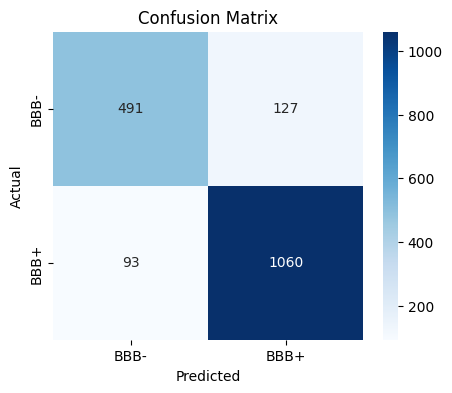

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["BBB-", "BBB+"],
    yticklabels=["BBB-", "BBB+"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

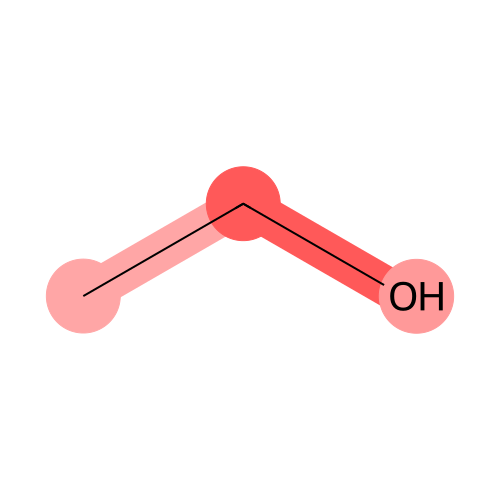

In [ ]:
from IPython.display import Image, display

smiles = "CCO"

atom_bins = {
    0: 3,
    1: 7,
    2: 5
}

highlight_molecule(
    smiles=smiles,
    atom_bins=atom_bins,
    label=1,
    output_path="/content/test_molecule.png"
)

display(Image("/content/test_molecule.png"))

In [17]:
import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.data import Data

# Settings
INPUT_PATH = "/content/test_mol_df.xlsx"
MODEL_PATH = "/content/best_model.pt"

OUTPUT_DIR = "/content/explanation_results"
FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(FIGURE_DIR, exist_ok=True)

MAX_MOLECULES = 20
EXPLAINER_EPOCHS = 2000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load test molecules
df, graphs = load_prediction_data(INPUT_PATH)
print("Valid molecules:", len(graphs))

# Load trained model
model = GraphConvModel(input_features=33,embedding_size=128)
model.load_state_dict(torch.load(MODEL_PATH,map_location=device))
model = model.to(device)
model.eval()
print("Model loaded successfully.")

# Create GNNExplainer
explainer = Explainer(model=model, algorithm=GNNExplainer( epochs=EXPLAINER_EPOCHS),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=dict( mode="binary_classification", task_level="graph", return_type="raw")
)
print("GNNExplainer created.")

# Generate explanations
for index in range(min(MAX_MOLECULES, len(graphs))):
    print()
    print("=" * 50)
    print("Molecule:", index)

    data = graphs[index].to(device)

    # One graph only
    batch_index = torch.zeros(data.x.size(0), dtype=torch.long,  device=device)

    # Model prediction
    with torch.no_grad():
        output = model(data.x, data.edge_index, batch_index)
        probability = torch.sigmoid(output).item()
        label = 1 if probability >= 0.5 else 0

    print("SMILES:", df.loc[index, "SMILES"])
    print("Probability:", probability)
    print("Prediction:", "BBB+" if label == 1 else "BBB-")

    # GNN explanation
    explanation = explainer(x=data.x, edge_index=data.edge_index, batch_index=batch_index)

    # Get REAL edge importance
    edge_mask = ( explanation.edge_mask.detach().cpu().numpy())
    edge_index = (data.edge_index.detach().cpu().numpy())
    print("Edge mask generated.")
    print("Number of edge scores:", len(edge_mask))

    # Convert edge importance → atom importance
    atom_bins = atom_importance(edge_index,edge_mask)
    print("Atom importance generated.")

    # Generate highlighted molecule
    output_path = os.path.join(FIGURE_DIR,f"molecule_{index}.png")
    highlight_molecule(smiles=df.loc[index, "SMILES"], atom_bins=atom_bins, label=label, output_path=output_path)
    print("Saved:", output_path)

print()
print("===================================")
print("Explanation generation complete.")
print("Images are in:", FIGURE_DIR)

Using device: cuda
Valid molecules: 1771
Model loaded successfully.
GNNExplainer created.

Molecule: 0
SMILES: NCc1c[n+]2ccccc2[nH]1
Probability: 0.7732346653938293
Prediction: BBB+
Edge mask generated.
Number of edge scores: 24
Atom importance generated.
Saved: /content/explanation_results/figures/molecule_0.png

Molecule: 1
SMILES: Nc1ccc(C(=O)O)cc1
Probability: 0.3426688015460968
Prediction: BBB-
Edge mask generated.
Number of edge scores: 20
Atom importance generated.
Saved: /content/explanation_results/figures/molecule_1.png

Molecule: 2
SMILES: O=C(O)c1ccccc1O
Probability: 0.4654970169067383
Prediction: BBB-
Edge mask generated.
Number of edge scores: 20
Atom importance generated.
Saved: /content/explanation_results/figures/molecule_2.png

Molecule: 3
SMILES: Nc1cc(N)c(N)cc1N
Probability: 0.657818615436554
Prediction: BBB+
Edge mask generated.
Number of edge scores: 20
Atom importance generated.
Saved: /content/explanation_results/figures/molecule_3.png

Molecule: 4
SMILES: CSC(=

Generated images: 20
molecule_0.png


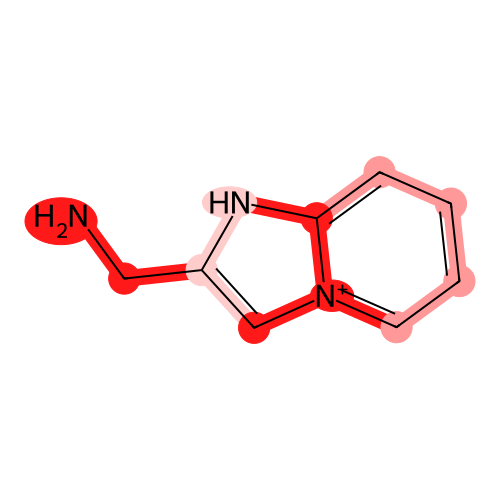

molecule_1.png


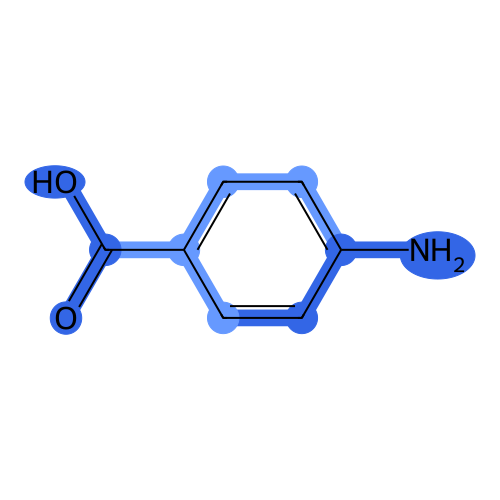

molecule_10.png


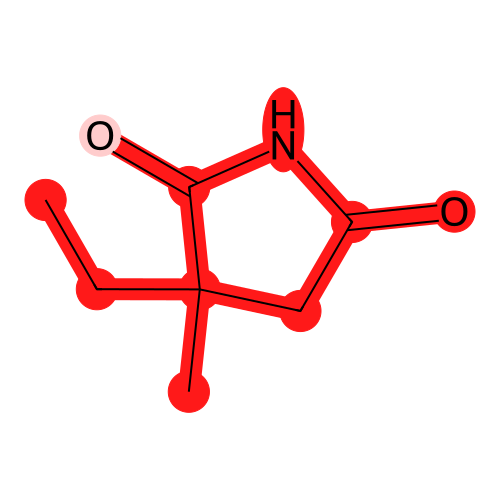

molecule_11.png


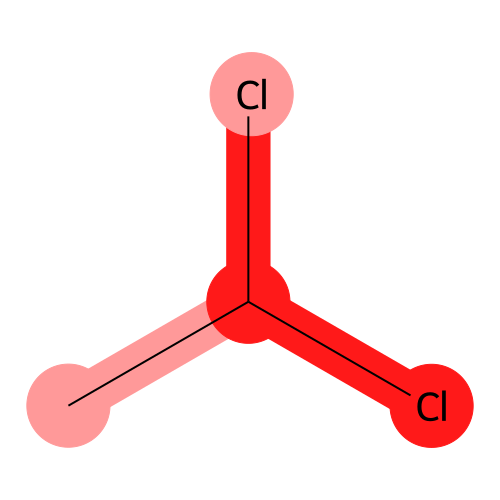

molecule_12.png


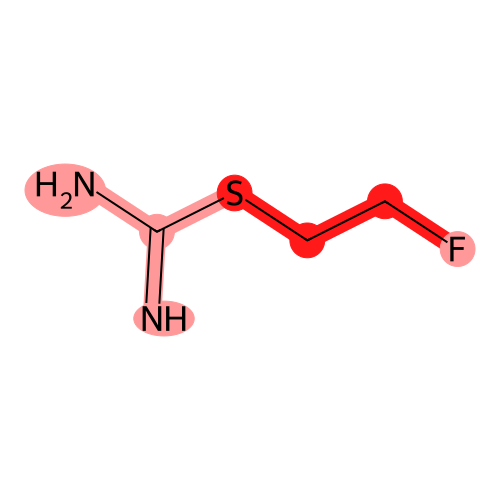

molecule_13.png


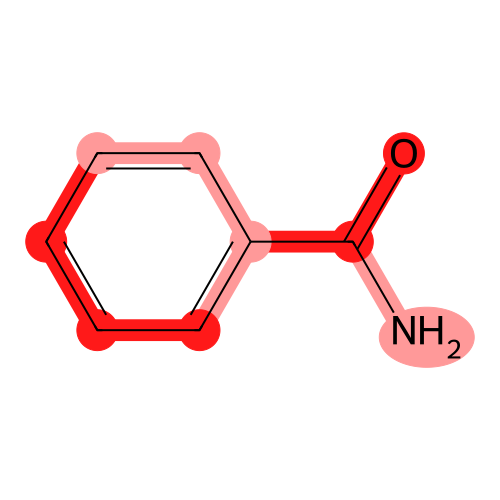

molecule_14.png


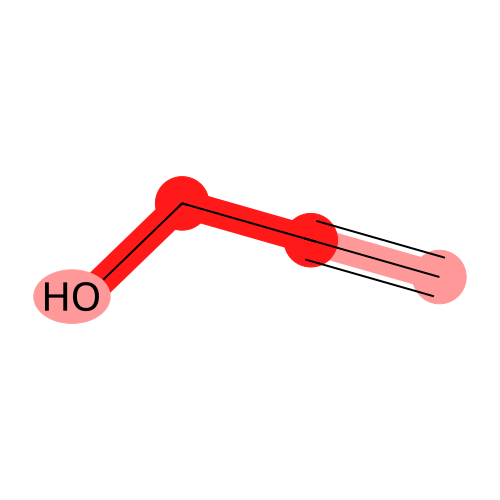

molecule_15.png


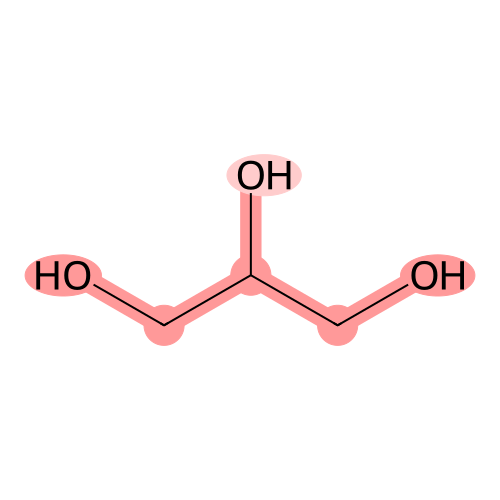

molecule_16.png


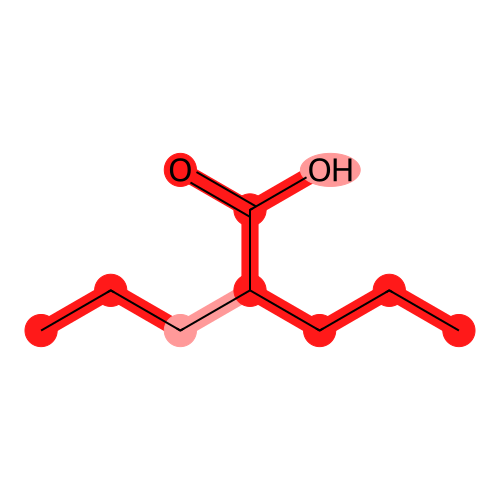

molecule_17.png


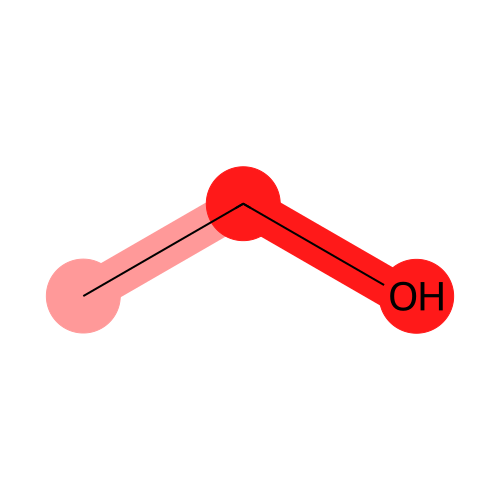

molecule_18.png


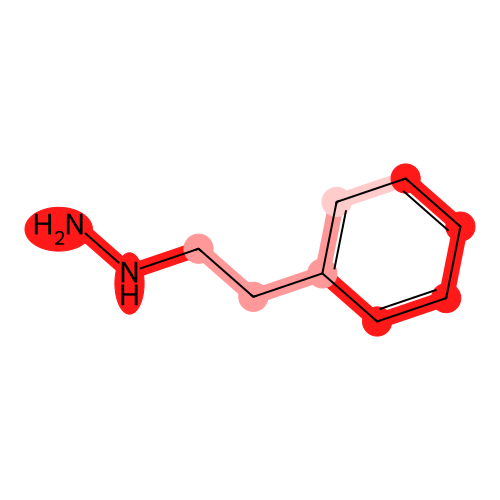

molecule_19.png


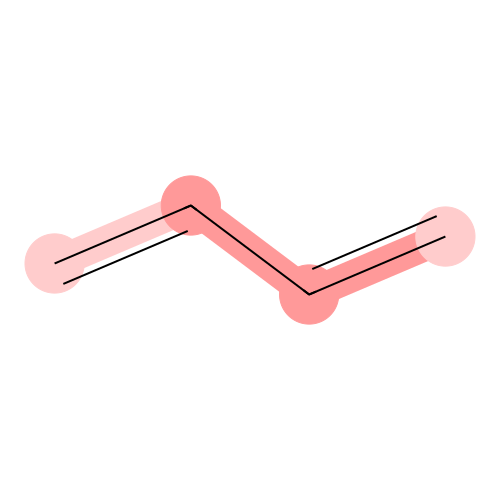

molecule_2.png


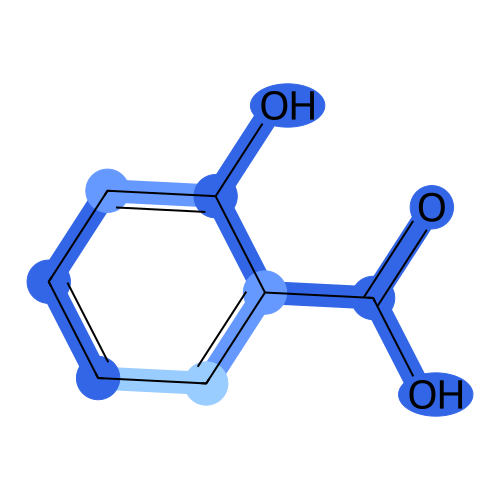

molecule_3.png


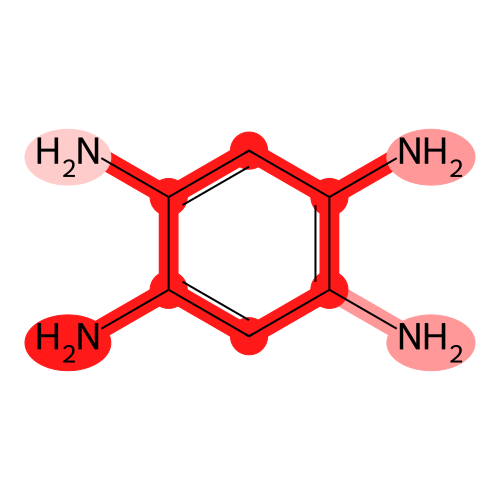

molecule_4.png


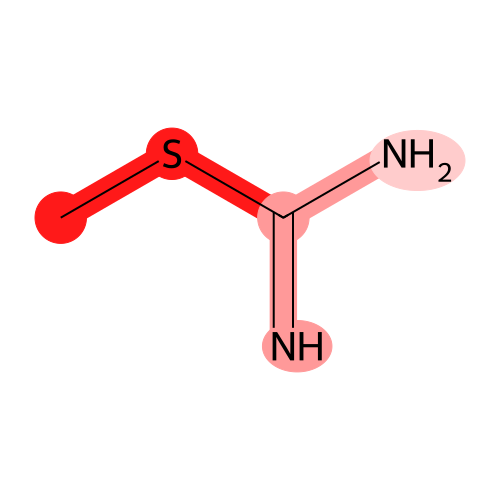

molecule_5.png


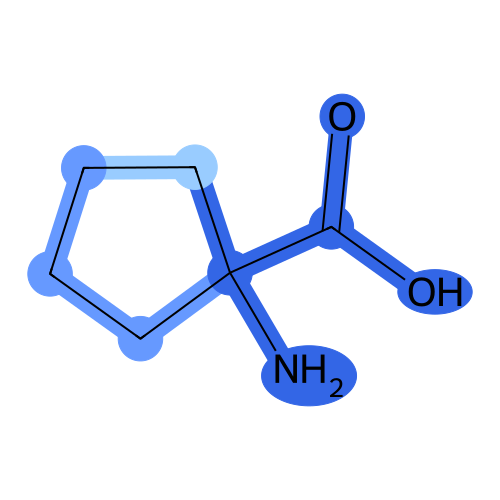

molecule_6.png


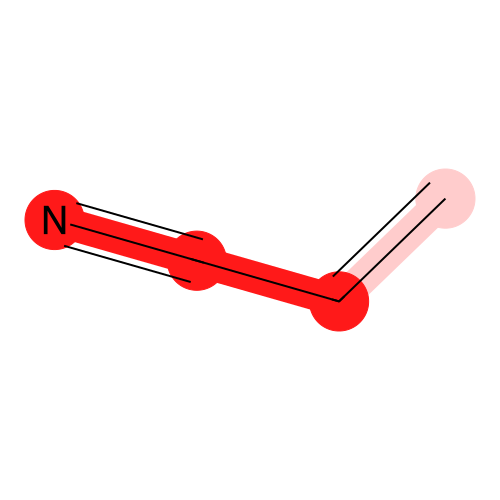

molecule_7.png


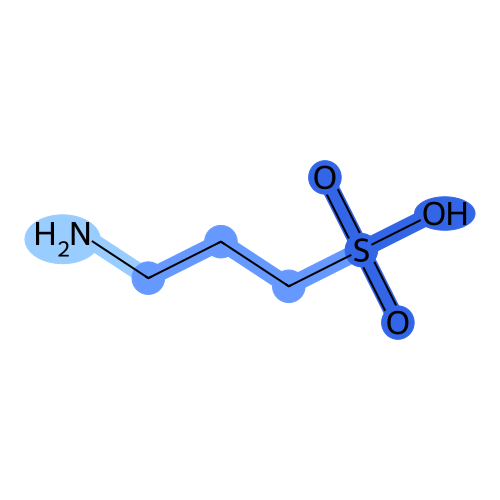

molecule_8.png


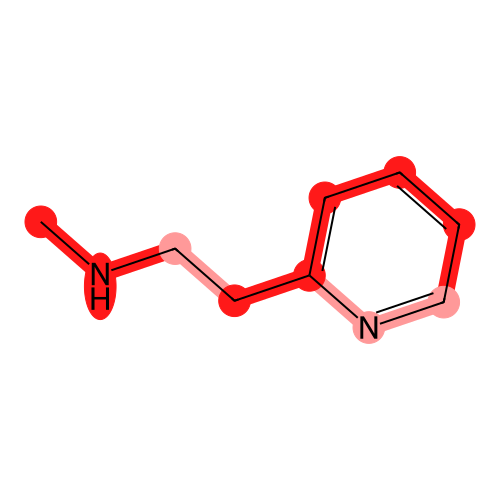

molecule_9.png


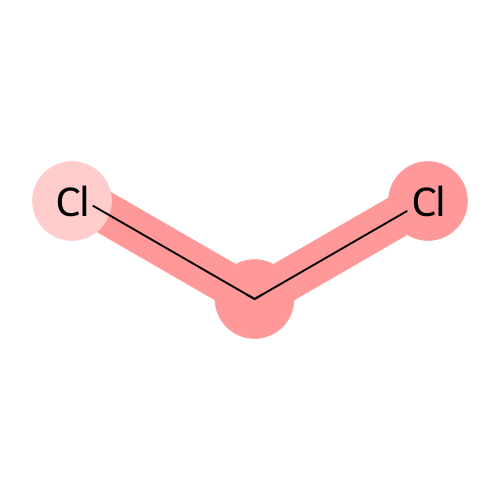

In [18]:
from IPython.display import Image, display
import os

figure_dir = "/content/explanation_results/figures"

files = sorted( f for f in os.listdir(figure_dir) if f.endswith(".png"))
print("Generated images:", len(files))

for file in files:
    print(file)
    display( Image(filename=os.path.join(figure_dir, file)))